# Figure S1: global AEM surveys

Maps the global distribution of public airborne-electromagnetic surveys.


In [1]:
import subprocess
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from shapely.geometry import GeometryCollection
from shapely.ops import unary_union


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'outputs').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root.')


ROOT = find_repo_root()
DATA_DIR = ROOT / 'data' / '13 Global AEM'
MRVA_BOUNDARY = ROOT / 'data' / '0 mask MRVA' / 'outerboundary.shp'
FOOTPRINTS_GEOJSON = DATA_DIR / 'derived' / 'global_aem_footprints.geojson'
AUS_REFINED_GEOJSON = DATA_DIR / 'AusAEM_footprint_refined_package' / 'AusAEM_footprint_refined.geojson'
NZ_REFINED_GEOJSON = DATA_DIR / 'Newzealand' / 'NZ_SkyTEM_regional_footprints.geojson'
CANADA_VERIFIED_GPKG = DATA_DIR / 'Canada' / 'Canada_AEM_verified_core_masks.gpkg'
DENMARK_REFINED_GEOJSON = DATA_DIR / 'Denmark' / 'Denmark_SkyTEM_union_2016.geojson'
INDONESIA_REFINED_GEOJSON = DATA_DIR / 'Indonesia' / 'Indonesia_West_Kalimantan_SkyTEM_survey_envelope.geojson'
MANIFEST_CSV = DATA_DIR / 'aem_public_datasets_manifest.csv'
OUT_DIR = ROOT / 'outputs' / 'figures' / 'FigS1'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PNG = OUT_DIR / 'FigS1_global_AEM_footprints.png'
SUMMARY_CSV = OUT_DIR / 'FigS1_global_AEM_footprint_summary.csv'


def display_path(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(ROOT))
    except ValueError:
        return str(path)


if not FOOTPRINTS_GEOJSON.exists():
    subprocess.run(
        [sys.executable, str(ROOT / 'tools' / 'download_global_aem_footprints.py')],
        cwd=ROOT,
        check=True,
    )

print('Footprints:', display_path(FOOTPRINTS_GEOJSON))
print('Output:', display_path(OUT_DIR))


Footprints: data\13 Global AEM\derived\global_aem_footprints.geojson
Output: outputs\figures\FigS1


In [2]:
footprints = gpd.read_file(FOOTPRINTS_GEOJSON).to_crs(4326)
footprints = footprints[footprints.geometry.notna() & ~footprints.geometry.is_empty].copy()
legacy_source_ids = {f'AEM{i:02d}' for i in range(44, 55)} | {f'AEM{i:02d}' for i in range(66, 70)} | {'AEM41', 'AEM42'}
footprints = footprints.loc[~footprints['source_id'].astype(str).isin(legacy_source_ids)].copy()
footprints['source_id'] = footprints['source_id'].astype(str)
footprints['footprint_source'] = footprints['footprint_source'].astype(str)
footprints['precision_rank'] = pd.to_numeric(footprints.get('precision_rank', 4), errors='coerce').fillna(4).astype(int)

def load_refined_footprints(path, source_prefix, *, layer=None, source_id=None, footprint_source='refined_regional_footprint', precision_rank=2):
    refined = gpd.read_file(path, layer=layer).to_crs(4326) if layer else gpd.read_file(path).to_crs(4326)
    refined = refined[refined.geometry.notna() & ~refined.geometry.is_empty].copy()
    if source_id is not None:
        refined['source_id'] = source_id
    elif 'program_id' in refined.columns:
        refined['source_id'] = 'CAN_' + refined['program_id'].astype(str).str.replace('BC_', '', regex=False)
    else:
        refined['source_id'] = [f'{source_prefix}_{i:02d}' for i in range(1, len(refined) + 1)]
    refined['footprint_source'] = footprint_source
    refined['precision_rank'] = precision_rank
    return refined

refined = pd.concat([
    load_refined_footprints(AUS_REFINED_GEOJSON, 'AUS_REFINED'),
    load_refined_footprints(NZ_REFINED_GEOJSON, 'NZ_REFINED'),
    load_refined_footprints(
        CANADA_VERIFIED_GPKG,
        'CAN_REFINED',
        layer='program_footprints_A1',
        footprint_source='refined_verified_footprint',
        precision_rank=1,
    ),
    load_refined_footprints(
        DENMARK_REFINED_GEOJSON,
        'DENMARK_REFINED',
        source_id='AEM55',
    ),
    load_refined_footprints(
        INDONESIA_REFINED_GEOJSON,
        'INDONESIA_REFINED',
        source_id='AEM70',
    ),
], ignore_index=True)
footprints = pd.concat([footprints, refined], ignore_index=True)
mrva_mask = gpd.read_file(MRVA_BOUNDARY).to_crs(4326).geometry.union_all()

manifest = pd.read_csv(MANIFEST_CSV)
expected_sources = (set(manifest['source_id'].astype(str)) - legacy_source_ids) | set(refined['source_id'])
represented_sources = set(footprints['source_id'].astype(str))
missing = sorted(expected_sources - represented_sources)
if missing:
    raise ValueError(f'Missing footprint representation for: {missing}')

source_summary = (
    footprints
    .drop(columns='geometry')
    .groupby(['source_id', 'footprint_source', 'precision_rank'], dropna=False)
    .size()
    .reset_index(name='n_features')
    .sort_values(['source_id', 'precision_rank', 'footprint_source'])
)
source_summary.to_csv(SUMMARY_CSV, index=False)

exact = footprints.loc[footprints['precision_rank'].eq(1)].copy()
grid = footprints.loc[
    footprints['precision_rank'].eq(2) & footprints['footprint_source'].eq('surface_grid_valid_data_footprint')
].copy()
refined = footprints.loc[footprints['footprint_source'].str.startswith('refined_')].copy()
metadata = footprints.loc[footprints['precision_rank'].eq(3)].copy()
approx = footprints.loc[footprints['precision_rank'].ge(4)].copy()
MRVA_EXACT_SOURCE_IDS = {'AEM05', 'AEM06', 'AEM07', 'AEM08', 'AEM09'}
MRVA_GRID_SOURCE_IDS = {'AEM10'}
LARGE_CANADA_SOURCE_IDS = {'AEM40'}
NATIONAL_INVENTORY_SOURCE_IDS = {'AEM01', 'AEM02'}
exact_global = exact.loc[
    ~exact['source_id'].isin(MRVA_EXACT_SOURCE_IDS | LARGE_CANADA_SOURCE_IDS)
    & ~exact['source_id'].isin(set(refined['source_id']))
].copy()
def remove_components_touching_mask(geometry, mask):
    parts = list(geometry.geoms) if hasattr(geometry, 'geoms') else [geometry]
    kept = [part for part in parts if not part.intersects(mask)]
    return unary_union(kept) if kept else GeometryCollection()

exact_global['geometry'] = exact_global.apply(
    lambda row: remove_components_touching_mask(row.geometry, mrva_mask)
    if row['source_id'] in NATIONAL_INVENTORY_SOURCE_IDS
    else row.geometry.difference(mrva_mask),
    axis=1,
)
exact_global = exact_global.loc[exact_global.geometry.notna() & ~exact_global.geometry.is_empty].copy()
grid['geometry'] = grid.apply(
    lambda row: row.geometry.intersection(mrva_mask)
    if row['source_id'] in MRVA_GRID_SOURCE_IDS else row.geometry,
    axis=1,
).copy()
grid = grid.loc[grid.geometry.notna() & ~grid.geometry.is_empty].copy()
visible_footprints = pd.concat([exact_global, grid, refined], ignore_index=True)

small_exact_points = exact_global.head(0).copy()

best_precision = footprints.groupby('source_id')['precision_rank'].min()
print(f'Sources represented: {len(represented_sources)} / {len(expected_sources)}')
print('Best source-level precision counts:')
print(best_precision.value_counts().sort_index().to_string())
print('Footprint feature counts:')
print(footprints['footprint_source'].value_counts().to_string())
print(f'Visible source geometries: {visible_footprints["source_id"].nunique()} sources')
print(f'Withheld low-precision extents from map: {pd.concat([metadata, approx], ignore_index=True)["source_id"].nunique()} sources')
withheld_large = MRVA_EXACT_SOURCE_IDS | LARGE_CANADA_SOURCE_IDS
print(f'Withheld MRVA and large-Canada geometries: {len(withheld_large)} source IDs')
print('MRVA core grid retained from AEM10; surrounding grid shell removed.')
print(f'Small exact-source markers: {len(small_exact_points)}')
print('Summary:', display_path(SUMMARY_CSV))



Sources represented: 61 / 61
Best source-level precision counts:
precision_rank
1    38
2    10
3     1
4    12
Footprint feature counts:
footprint_source
downloaded_vector_geometry            79
approx_from_description               14
refined_regional_footprint             8
downloaded_csv_flightline_geometry     6
downloaded_csv_survey_point_hull       3
surface_grid_valid_data_footprint      2
refined_verified_footprint             2
sciencebase_bbox                       1
Visible source geometries: 42 sources
Withheld low-precision extents from map: 15 sources
Withheld MRVA and large-Canada geometries: 6 source IDs
MRVA core grid retained from AEM10; surrounding grid shell removed.
Small exact-source markers: 0
Summary: outputs\figures\FigS1\FigS1_global_AEM_footprint_summary.csv


In [3]:

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 7,
    'legend.frameon': False,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

projection = ccrs.Robinson(central_longitude=0)
plate_carree = ccrs.PlateCarree()
fig = plt.figure(figsize=(7.2, 3.85), dpi=600, facecolor='white')
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.set_global()

ocean_50m = cfeature.NaturalEarthFeature(
    'physical', 'ocean', '50m', facecolor='#EAF3F6', edgecolor='none'
)
land_50m = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m', facecolor='#F5F2EA', edgecolor='none'
)
coastline_50m = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '50m', facecolor='none', edgecolor='#98A3A8'
)
ax.add_feature(ocean_50m, zorder=0)
ax.add_feature(land_50m, zorder=1)
ax.add_feature(coastline_50m, linewidth=0.35, zorder=2)

AEM_FILL = '#2A9D8F'
if len(visible_footprints):
    ax.add_geometries(
        visible_footprints.geometry,
        crs=plate_carree,
        facecolor=AEM_FILL,
        edgecolor='#176C64',
        linewidth=0.30,
        zorder=3,
    )

indonesia = refined.loc[refined['source_id'].eq('AEM70')]
if len(indonesia):
    ax.add_geometries(
        indonesia.geometry,
        crs=plate_carree,
        facecolor=AEM_FILL,
        edgecolor='#176C64',
        linewidth=0.70,
        zorder=4,
    )

ax.spines['geo'].set_edgecolor('#4A4A4A')
ax.spines['geo'].set_linewidth(0.65)
ax.legend(
    handles=[Patch(facecolor=AEM_FILL, edgecolor='#176C64', linewidth=0.45, label='AEM survey')],
    loc='lower left',
    bbox_to_anchor=(0.015, 0.025),
    fontsize=7,
    handlelength=1.25,
    handleheight=0.85,
    borderaxespad=0,
)

fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.98)
fig.savefig(FIG_PNG, dpi=600, bbox_inches='tight', facecolor='white')
plt.close(fig)
print('Saved:', display_path(FIG_PNG))




Saved: outputs\figures\FigS1\FigS1_global_AEM_footprints.png


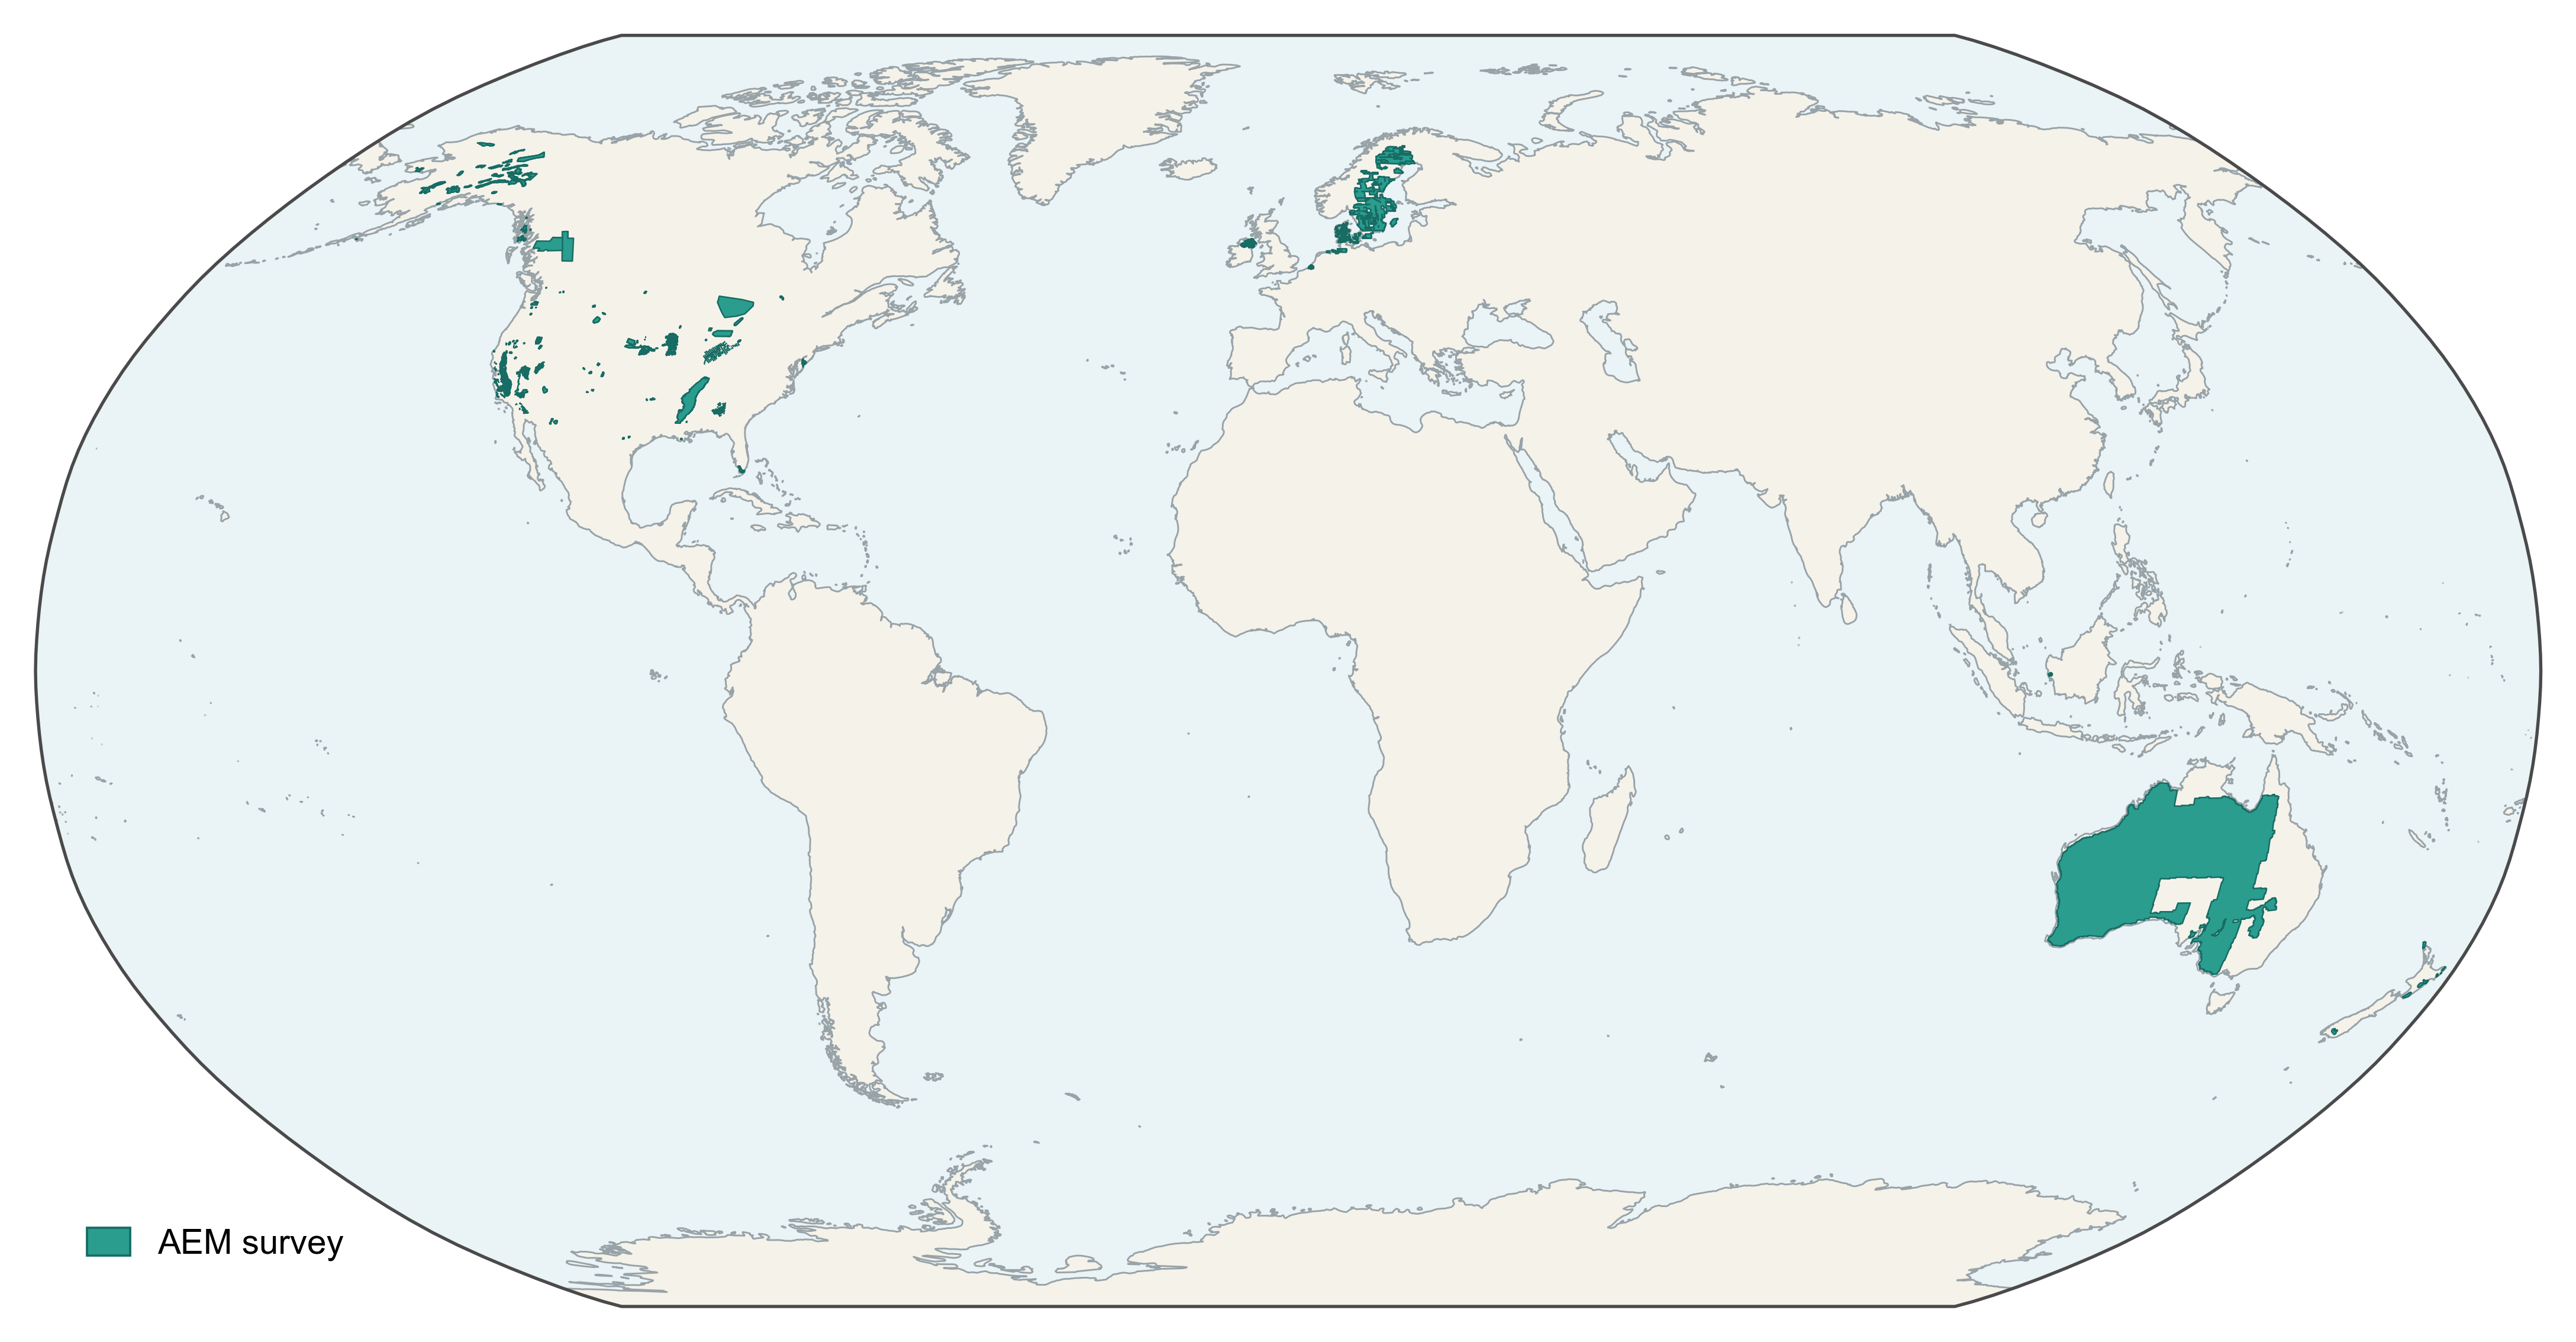

In [4]:
try:
    from IPython.display import Image, display
    display(Image(filename=str(FIG_PNG)))
except Exception:
    pass
